In [1]:
import pandas as pd

data=pd.read_csv('/Users/medhanshpindi/Desktop/IntelliUnderwrite/IntelliUnderwrite/ML/Dataset/accepted_2007_to_2018Q4.csv')

df=pd.DataFrame(data)
df.head(5)


/var/folders/qj/pnj1tcsd4q3gxpt050rznh4m0000gn/T/ipykernel_56257/2315351518.py:3: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv('/Users/medhanshpindi/Desktop/IntelliUnderwrite/IntelliUnderwrite/ML/Dataset/accepted_2007_to_2018Q4.csv')


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
for col in df.columns:
    print(col)

id
member_id
loan_amnt
funded_amnt
funded_amnt_inv
term
int_rate
installment
grade
sub_grade
emp_title
emp_length
home_ownership
annual_inc
verification_status
issue_d
loan_status
pymnt_plan
url
desc
purpose
title
zip_code
addr_state
dti
delinq_2yrs
earliest_cr_line
fico_range_low
fico_range_high
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_bal
revol_util
total_acc
initial_list_status
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
last_fico_range_high
last_fico_range_low
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
tot_coll_amt
tot_cur_bal
open_acc_6m
open_act_il
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
open_rv_24m
max_bal_bc
all_util
total_rev_hi_lim
inq_fi
to

In [3]:
cols_to_extract = [
    'loan_status',
    'loan_amnt',
    'dti',
    'annual_inc',
    'emp_length',
    'delinq_2yrs',
    'avg_cur_bal',
    'fico_range_low',
    'revol_util'
]
df1=df[cols_to_extract]
df1.head(5)

,loan_status,loan_amnt,dti,annual_inc,emp_length,delinq_2yrs,avg_cur_bal,fico_range_low,revol_util
0,Fully Paid,3600.0,5.91,55000.0,10+ years,0.0,20701.0,675.0,29.7
1,Fully Paid,24700.0,16.06,65000.0,10+ years,1.0,9733.0,715.0,19.2
2,Fully Paid,20000.0,10.78,63000.0,10+ years,0.0,31617.0,695.0,56.2
3,Current,35000.0,17.06,110000.0,10+ years,0.0,23192.0,785.0,11.6
4,Fully Paid,10400.0,25.37,104433.0,3 years,1.0,27644.0,695.0,64.5


In [4]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   loan_status     str    
 1   loan_amnt       float64
 2   dti             float64
 3   annual_inc      float64
 4   emp_length      str    
 5   delinq_2yrs     float64
 6   avg_cur_bal     float64
 7   fico_range_low  float64
 8   revol_util      float64
dtypes: float64(7), str(2)
memory usage: 155.2 MB


In [5]:
#handling null values

In [6]:
df1.isna().sum()

loan_status           33
loan_amnt             33
dti                 1744
annual_inc            37
emp_length        146940
delinq_2yrs           62
avg_cur_bal        70379
fico_range_low        33
revol_util          1835
dtype: int64

In [7]:
df1 = df1.dropna(subset=['loan_status', 'loan_amnt', 'dti', 'annual_inc', 
    'delinq_2yrs', 'avg_cur_bal', 'fico_range_low', 'revol_util'])


In [8]:
df1['emp_length'] = df1['emp_length'].str.extract(r'(\d+)').astype(float)

df1['emp_length'] = df1['emp_length'].fillna(0)

In [9]:
df1.isna().sum()


loan_status       0
loan_amnt         0
dti               0
annual_inc        0
emp_length        0
delinq_2yrs       0
avg_cur_bal       0
fico_range_low    0
revol_util        0
dtype: int64

In [10]:
df1.duplicated().sum()

np.int64(1)

In [11]:
df1.drop_duplicates(inplace=True)

In [12]:
df1.info()

<class 'pandas.DataFrame'>
Index: 2187003 entries, 0 to 2260698
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   loan_status     str    
 1   loan_amnt       float64
 2   dti             float64
 3   annual_inc      float64
 4   emp_length      float64
 5   delinq_2yrs     float64
 6   avg_cur_bal     float64
 7   fico_range_low  float64
 8   revol_util      float64
dtypes: float64(8), str(1)
memory usage: 166.9 MB


In [13]:
df1['loan_status'].value_counts()

loan_status
Fully Paid            1018619
Current                876153
Charged Off            258015
Late (31-120 days)      21416
In Grace Period          8419
Late (16-30 days)        4341
Default                    40
Name: count, dtype: int64

In [14]:
import numpy as np
# 1. Filter out all active/intermediate loans
resolved_statuses = ['Fully Paid', 'Charged Off']
df_resolved = df1[df1['loan_status'].isin(resolved_statuses)].copy()

# 2. Create the binary target variable (1 = Default, 0 = Good Loan)
# Note: We group the 40 'Default' rows into 'Charged Off' if you choose to include them, 
# but sticking to just the two main categories is cleaner for this prototype.
df_resolved['target'] = np.where(df_resolved['loan_status'] == 'Charged Off', 1, 0)

# 3. Drop the original text column
df_resolved = df_resolved.drop(columns=['loan_status'])

In [15]:
df_resolved['target'].value_counts()

target
0    1018619
1     258015
Name: count, dtype: int64

In [16]:
from sklearn.utils import resample
import pandas as pd

# 1. Separate the dataset into majority (0) and minority (1) classes
df_majority = df_resolved[df_resolved['target'] == 0]
df_minority = df_resolved[df_resolved['target'] == 1]

# 2. Downsample the majority class to exactly match the minority class size
df_majority_downsampled = resample(
    df_majority, 
    replace=False,              # Sample without replacement
    n_samples=len(df_minority), # Match the exact count of 258,015 defaults
    random_state=42
)

# 3. Combine the minority class with the newly downsampled majority class
df_balanced = pd.concat([df_majority_downsampled, df_minority])

# 4. Shuffle the dataset to ensure random distribution during training
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# 5. Verify the perfect 50/50 distribution
print("--- New Balanced Distribution ---")
print(df_balanced['target'].value_counts())
print(f"\nNew dataset shape: {df_balanced.shape}")

--- New Balanced Distribution ---
target
0    258015
1    258015
Name: count, dtype: int64

New dataset shape: (516030, 9)


In [17]:
df_balanced.head(5)

,loan_amnt,dti,annual_inc,emp_length,delinq_2yrs,avg_cur_bal,fico_range_low,revol_util,target
0,30000.0,12.36,70000.0,1.0,0.0,8717.0,665.0,81.9,0
1,11625.0,22.66,51958.4,10.0,0.0,25238.0,720.0,80.7,1
2,18000.0,18.96,76300.0,10.0,0.0,15065.0,705.0,76.4,1
3,10800.0,13.49,90000.0,2.0,1.0,3993.0,670.0,36.4,0
4,8000.0,35.39,68500.0,8.0,1.0,3073.0,665.0,38.3,0


In [18]:
df_balanced.describe()

,loan_amnt,dti,annual_inc,emp_length,delinq_2yrs,avg_cur_bal,fico_range_low,revol_util,target
count,516030.000000,516030.000000,5.160300e+05,516030.000000,516030.000000,516030.000000,516030.000000,516030.000000,516030.0
mean,14953.638839,19.184340,7.443081e+04,5.644724,0.338637,12535.334736,692.380152,52.877354,0.5
std,8783.218526,11.410997,6.929222e+04,3.763888,0.913659,15195.532985,29.692644,24.191624,0.5
min,1000.000000,-1.000000,2.000000e+01,0.000000,0.000000,0.000000,660.000000,0.000000,0.0
25%,8000.000000,12.570000,4.500000e+04,2.000000,0.000000,2976.000000,670.000000,35.000000,0.0
50%,13000.000000,18.610000,6.331100e+04,5.000000,0.000000,6685.000000,685.000000,53.400000,0.5
75%,20000.000000,25.200000,9.000000e+04,10.000000,0.000000,17291.000000,705.000000,71.500000,1.0
max,40000.000000,999.000000,9.550000e+06,10.000000,39.000000,502002.000000,845.000000,892.300000,1.0


In [19]:
#cleaning outliers

In [20]:





df_clean = df_balanced.copy()

print("--- Max Values BEFORE Treatment ---")
print(df_clean[['annual_inc', 'dti', 'avg_cur_bal']].max())

# 1. Capping (Winsorization) at the 99th Percentile
# This flattens extreme edge cases without deleting the rows entirely
features_to_cap = ['annual_inc', 'dti', 'avg_cur_bal', 'revol_util']

for col in features_to_cap:
    # Calculate the 99th percentile limit
    upper_limit = df_clean[col].quantile(0.99)
    # Replace any value above the limit with the limit itself
    df_clean[col] = np.where(df_clean[col] > upper_limit, upper_limit, df_clean[col])

# 2. Log Transformation for Monetary Columns
# Smooths out large financial numbers to create a normal distribution
df_clean['annual_inc_log'] = np.log1p(df_clean['annual_inc'])
df_clean['avg_cur_bal_log'] = np.log1p(df_clean['avg_cur_bal'])

# Drop the original un-logged columns to prevent multi-collinearity
df_clean = df_clean.drop(columns=['annual_inc', 'avg_cur_bal'])

print("\n--- Max Values AFTER Treatment ---")
print(df_clean[['annual_inc_log', 'dti', 'avg_cur_bal_log']].max())

--- Max Values BEFORE Treatment ---
annual_inc     9550000.0
dti                999.0
avg_cur_bal     502002.0
dtype: float64

--- Max Values AFTER Treatment ---
annual_inc_log     12.429220
dti                39.030000
avg_cur_bal_log    11.140834
dtype: float64


In [21]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score



X = df_clean.drop(columns=['target'])
y = df_clean['target']

# 3. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Standardize the Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train the Logistic Regression Model
# class_weight='balanced' forces the model to care equally about defaults
risk_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
risk_model.fit(X_train_scaled, y_train)

# 6. Evaluate Performance
y_pred = risk_model.predict(X_test_scaled)
y_pred_proba = risk_model.predict_proba(X_test_scaled)[:, 1]

print("--- IntelliUnderwrite Risk Engine Performance ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

--- IntelliUnderwrite Risk Engine Performance ---
              precision    recall  f1-score   support

           0       0.62      0.58      0.60     51603
           1       0.60      0.64      0.62     51603

    accuracy                           0.61    103206
   macro avg       0.61      0.61      0.61    103206
weighted avg       0.61      0.61      0.61    103206

ROC-AUC Score: 0.6533


In [22]:
#hyperparameter tuning

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report
import time

# Define the models and their respective parameter grids
model_grids = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=2000, random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear'] 
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10],
            'min_samples_split': [2, 5]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(eval_metric='logloss', random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 5],
        }
    }
}

best_overall_model = None
best_overall_score = 0.0
best_overall_name = ""

# Iterate through the dictionary and run GridSearchCV for each algorithm
for model_name, config in model_grids.items():
    print(f"Training {model_name}...")
    start_time = time.time()
    
    # CHANGED TO n_jobs=1 TO PREVENT MAC MULTIPROCESSING CRASH
    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        scoring='roc_auc',
        cv=5,
        n_jobs=1 
    )
    
    grid_search.fit(X_train_scaled, y_train)
    elapsed_time = time.time() - start_time
    
    # Extract the best model from this specific grid
    best_model = grid_search.best_estimator_
    y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"Best Params: {grid_search.best_params_}")
    print(f"ROC-AUC: {roc_auc:.4f} (Time: {elapsed_time:.1f}s)\n")
    
    # Track the global champion
    if roc_auc > best_overall_score:
        best_overall_score = roc_auc
        best_overall_model = best_model
        best_overall_name = model_name

print("-" * 40)
print(f"🏆 Champion Model: {best_overall_name} with ROC-AUC: {best_overall_score:.4f}")

# Final evaluation of the winning model
y_pred_champ = best_overall_model.predict(X_test_scaled)
print("\nChampion Classification Report:")
print(classification_report(y_test, y_pred_champ))

Training Logistic Regression...


/Users/medhanshpindi/Desktop/IntelliUnderwrite/IntelliUnderwrite/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/medhanshpindi/Desktop/IntelliUnderwrite/IntelliUnderwrite/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/medhanshpindi/Desktop/IntelliUnderwrite/IntelliUnderwrite/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will

Best Params: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
ROC-AUC: 0.6533 (Time: 6.5s)

Training Random Forest...
Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
ROC-AUC: 0.6601 (Time: 1012.9s)

Training XGBoost...
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
ROC-AUC: 0.6648 (Time: 33.4s)

----------------------------------------
🏆 Champion Model: XGBoost with ROC-AUC: 0.6648

Champion Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.59      0.61     51603
           1       0.61      0.65      0.63     51603

    accuracy                           0.62    103206
   macro avg       0.62      0.62      0.62    103206
weighted avg       0.62      0.62      0.62    103206



In [24]:
# 1. Print the raw model object
print("--- Champion Model Architecture ---")
print(best_overall_model)

# 2. Extract and format just the hyperparameters for your documentation
print("\n--- Winning Hyperparameters ---")
for param, value in best_overall_model.get_params().items():
    # Filtering out default XGBoost backend parameters to just show what matters
    if param in ['learning_rate', 'max_depth', 'n_estimators', 'objective']:
        print(f"{param}: {value}")

--- Champion Model Architecture ---
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

--- Winning Hyperparameters ---
objective: binary:logistic
learning_rate: 0.1
max_depth: 5
n_estimators: 200


In [25]:
import joblib

# 1. Bundle the model, scaler, and exact feature order into a single dictionary
model_artifact = {
    'model': best_overall_model,
    'scaler': scaler,
    'features': list(X.columns)
}

# 2. Export the bundle to your local directory
export_path = 'intelliunderwrite_xgboost.pkl'
joblib.dump(model_artifact, export_path)

print(f"--- Export Complete ---")
print(f"Pipeline successfully saved to: {export_path}")
print(f"Features expected by API: {model_artifact['features']}")

--- Export Complete ---
Pipeline successfully saved to: intelliunderwrite_xgboost.pkl
Features expected by API: ['loan_amnt', 'dti', 'emp_length', 'delinq_2yrs', 'fico_range_low', 'revol_util', 'annual_inc_log', 'avg_cur_bal_log']


/Users/medhanshpindi/Desktop/IntelliUnderwrite/IntelliUnderwrite/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Matplotlib is building the font cache; this may take a moment.


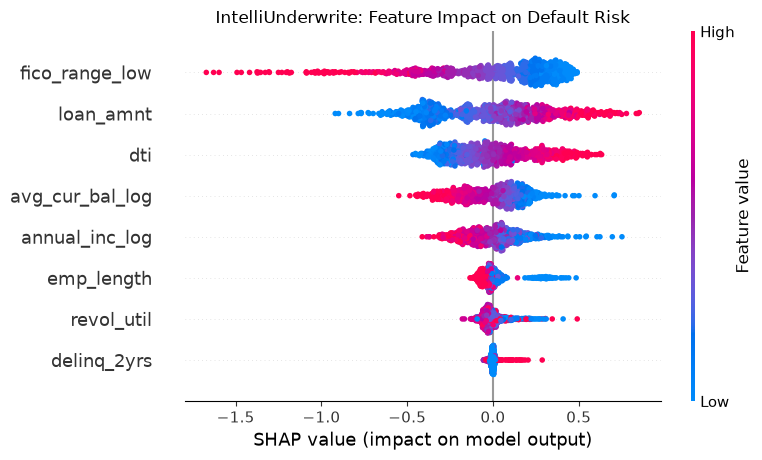

In [26]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the C++ optimized TreeExplainer for the XGBoost champion
explainer = shap.TreeExplainer(best_overall_model)

# 2. Slice a 1,000-row sample from the test set
# SHAP calculates every possible feature permutation. Slicing prevents Jupyter UI freezes.
X_test_sample = X_test_scaled[:1000]
shap_values = explainer.shap_values(X_test_sample)

# 3. Render the SHAP Summary Plot
plt.figure(figsize=(10, 6))
plt.title("IntelliUnderwrite: Feature Impact on Default Risk")
shap.summary_plot(shap_values, X_test_sample, feature_names=X.columns)

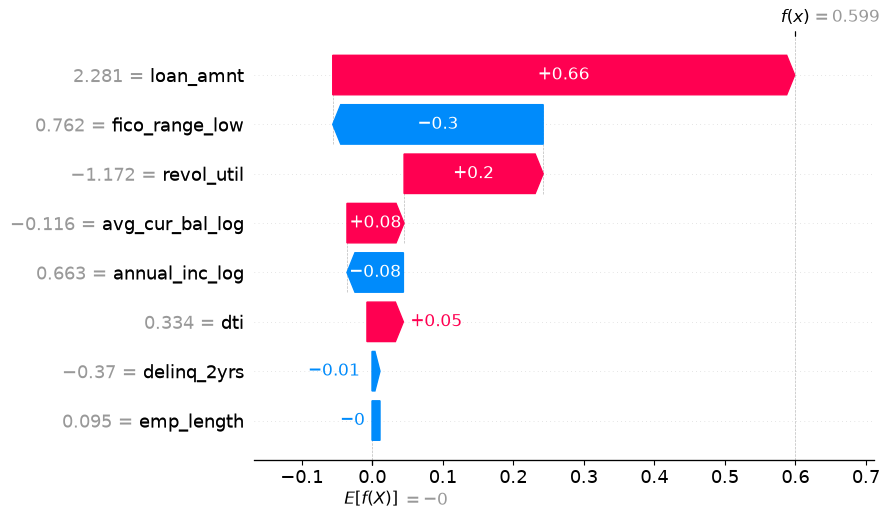

In [28]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

# 1. Convert the raw NumPy array back to a DataFrame with column names
X_test_sample_df = pd.DataFrame(X_test_scaled[:1000], columns=X.columns)

# 2. Generate the SHAP Explanation object using the labeled DataFrame
explanations = explainer(X_test_sample_df)

# 3. Render the Waterfall plot for Applicant 0
plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanations[0])